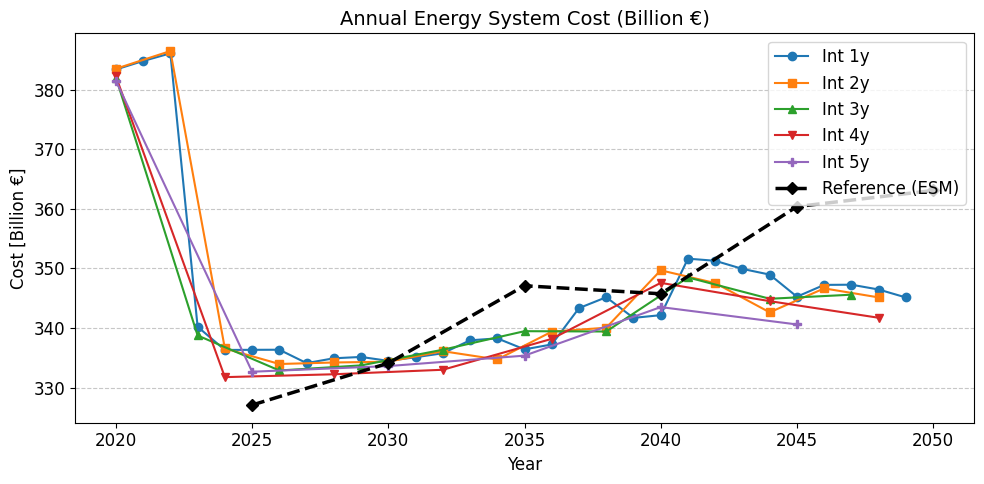

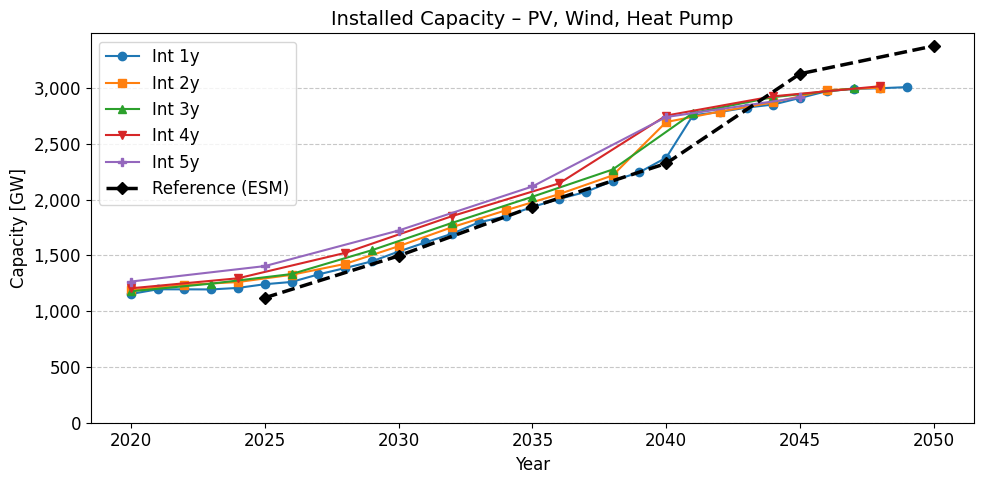

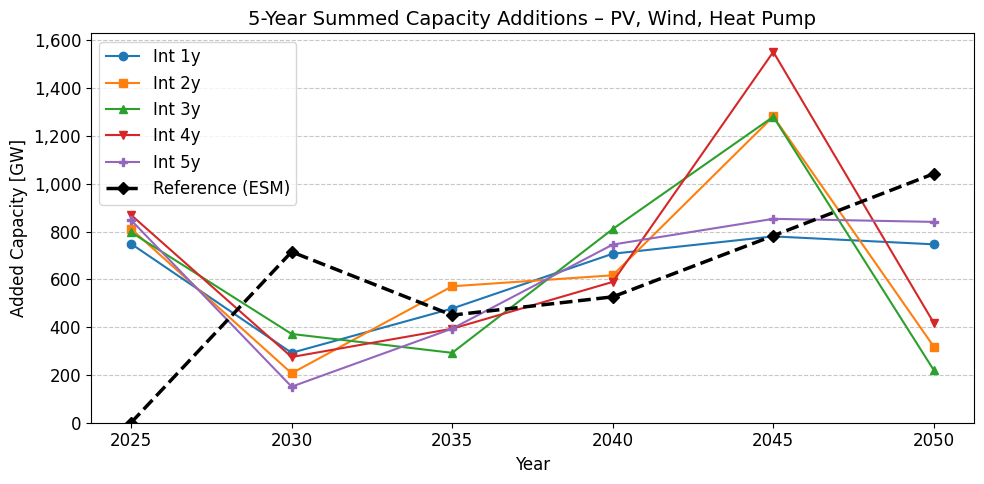

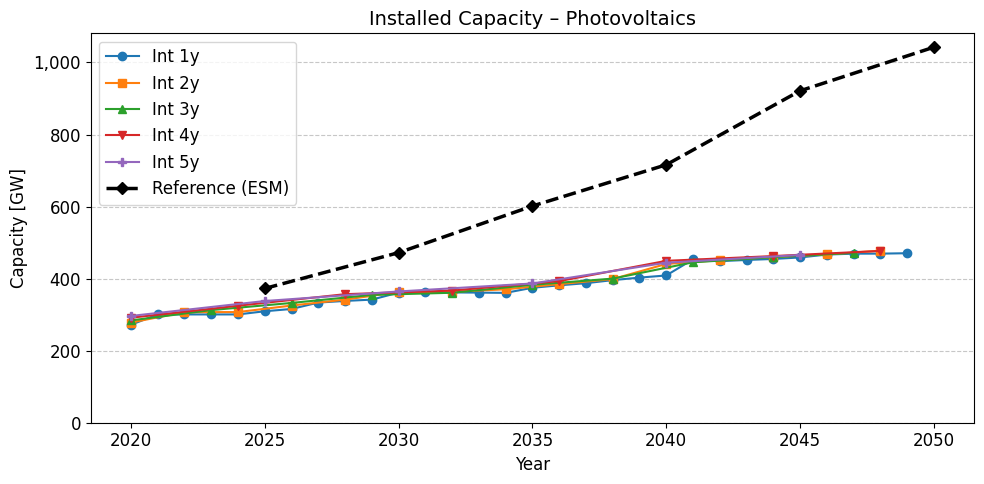

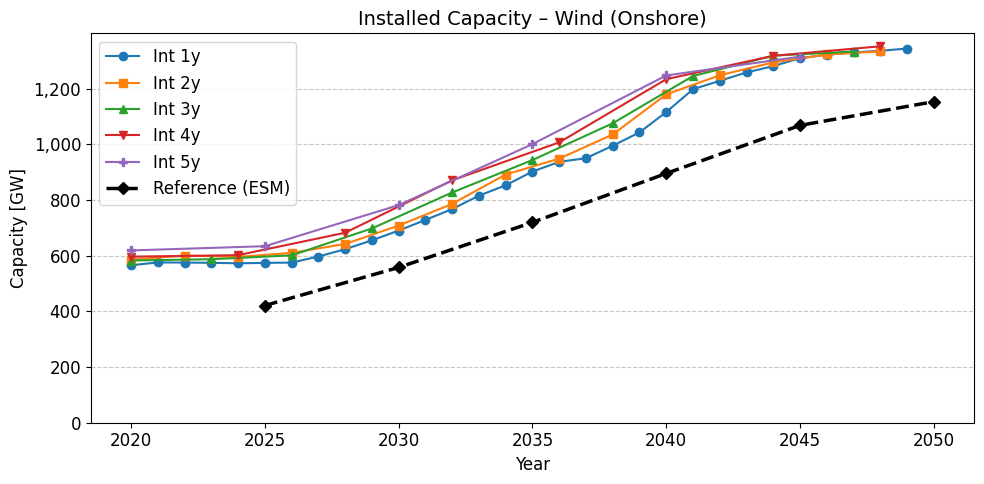

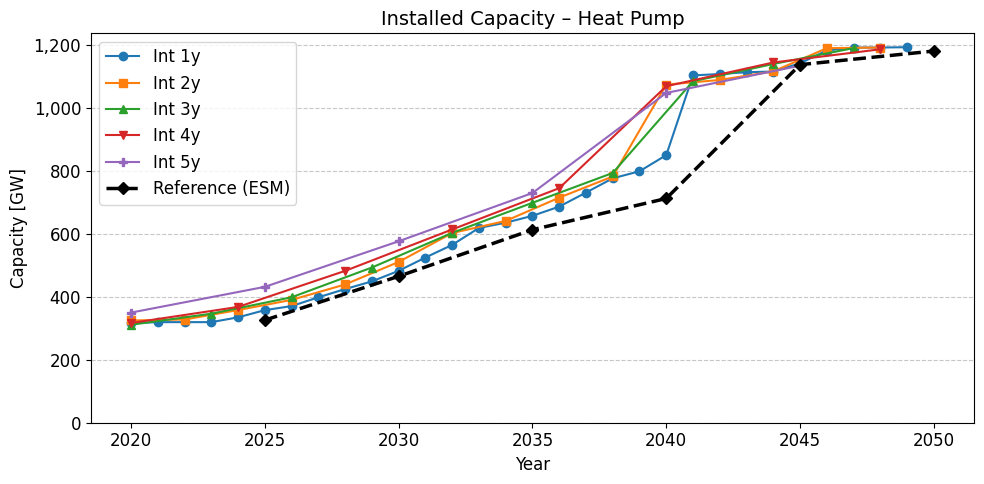

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
input_datasets = [
    '2020_50ts_30a_1',  # 1-year interval
    '2020_50ts_30a_2',  # 2-year interval
    '2020_50ts_30a_3',  # 3-year interval
    '2020_50ts_30a_4',  # 4-year interval
    '2020_50ts_30a_5',  # 5-year interval
    'energy_transition_example_output',  # reference
]

input_labels = ['int_1y', 'int_2y', 'int_3y', 'int_4y', 'int_5y', 'ref_esm']

paths_input = [os.path.join("outputs", name) for name in input_datasets]
results_input = [Results(path) for path in paths_input]

input_start_years = {
    'int_1y': 2020,
    'int_2y': 2020,
    'int_3y': 2020,
    'int_4y': 2020,
    'int_5y': 2020,
    'ref_esm': 2025,
}

input_intervals = {
    'int_1y': 1,
    'int_2y': 2,
    'int_3y': 3,
    'int_4y': 4,
    'int_5y': 5,
    'ref_esm': 5,
}

conversion_techs = ['photovoltaics', 'wind_onshore', 'heat_pump']

# === Define save path
save_path = r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\ESM_plots\ts_interval_comparison"
os.makedirs(save_path, exist_ok=True)

# === Styling
plt.rcParams.update({'font.size': 12})

marker_styles = {
    'int_1y': 'o',
    'int_2y': 's',
    'int_3y': '^',
    'int_4y': 'v',
    'int_5y': 'P',
    'ref_esm': 'D'
}

colors = {
    'int_1y': '#1f77b4',
    'int_2y': '#ff7f0e',
    'int_3y': '#2ca02c',
    'int_4y': '#d62728',
    'int_5y': '#9467bd',
    'ref_esm': 'black'
}

# === Cost Comparison Plot ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cost = res.get_total('cost_total')  # in MEUR
        start_year = input_start_years[label]
        step = input_intervals[label]
        cost.index = list(range(start_year, start_year + len(cost) * step, step))
        cost_in_beuro = cost * 1e6 / 1e9  # MEUR → EUR → Billion €

        plt.plot(cost_in_beuro.index, cost_in_beuro.values,
                 marker=marker_styles[label],
                 linestyle='--' if label == 'ref_esm' else '-',
                 linewidth=2.5 if label == 'ref_esm' else 1.5,
                 color=colors[label],
                 label='Reference (ESM)' if label == 'ref_esm' else label.replace("_", " ").capitalize())

    plt.title('Annual Energy System Cost (Billion €)', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Cost [Billion €]')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    for fmt in ['pdf', 'png']:
        plt.savefig(os.path.join(save_path, f"energy_system_cost_ts_interval.{fmt}"), format=fmt, bbox_inches='tight', dpi=300)

    plt.show()
except Exception as e:
    print(f"Error plotting cost_total: {e}")

# === Reusable Plot Function ===
def plot_series(title, y_label, component, tech_filter=None, binning=False, ylim_bottom=0):
    try:
        plt.figure(figsize=(10, 5))
        for res, label in zip(results_input, input_labels):
            df = res.get_total(component)
            start_year = input_start_years[label]
            step = input_intervals[label]
            df.columns = list(range(start_year, start_year + df.shape[1] * step, step))

            if tech_filter and 'technology' in df.index.names:
                df = df.loc[df.index.get_level_values('technology').isin(tech_filter)]

            total = df.sum(axis=0)

            if binning:
                bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
                bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]
                binned = pd.cut(total.index, bins=bin_edges, labels=bin_labels, right=False)
                total = total.groupby(binned, observed=False).sum()
                total.index = total.index.astype(int)

            plt.plot(total.index, total.values,
                     marker=marker_styles[label],
                     linestyle='--' if label == 'ref_esm' else '-',
                     linewidth=2.5 if label == 'ref_esm' else 1.5,
                     color=colors[label],
                     label='Reference (ESM)' if label == 'ref_esm' else label.replace("_", " ").capitalize())

        plt.title(title, fontsize=14)
        plt.xlabel('Year')
        plt.ylabel(y_label)
        plt.ylim(bottom=ylim_bottom)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
        plt.legend(loc='upper left')
        plt.tight_layout()
        filename = title.replace("–", "-").replace(" ", "_").replace("(", "").replace(")", "").lower()
        for fmt in ['pdf', 'png']:
            plt.savefig(os.path.join(save_path, f"{filename}.{fmt}"), format=fmt, bbox_inches='tight', dpi=300)
        plt.show()
    except Exception as e:
        print(f"Error plotting {title.lower()}: {e}")

# === Plot Calls
plot_series(
    title='Installed Capacity – PV, Wind, Heat Pump',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=conversion_techs,
    ylim_bottom=0
)

plot_series(
    title='5-Year Summed Capacity Additions – PV, Wind, Heat Pump',
    y_label='Added Capacity [GW]',
    component="capacity_addition",
    tech_filter=conversion_techs,
    binning=True,
    ylim_bottom=0
)

# === Installed Capacity – PV only
plot_series(
    title='Installed Capacity – Photovoltaics',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['photovoltaics'],
    ylim_bottom=0
)

# === Installed Capacity – Wind (Onshore) only
plot_series(
    title='Installed Capacity – Wind (Onshore)',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['wind_onshore'],
    ylim_bottom=0
)

# === Installed Capacity – Heat Pump only
plot_series(
    title='Installed Capacity – Heat Pump',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['heat_pump'],
    ylim_bottom=0
)
